# Latency Analysis
Reads the latency CSV log and reproduces the 5-panel time-series plots:
**RTT_ms**, **Processing_ms**, **Network_ms**, **RenderDelay_ms**, **MTP_ms** over elapsed time (seconds).

Outliers (values > mean + 2×std) are highlighted with red dots. A dashed line shows the mean.

In [18]:
try:
    import pandas, matplotlib, numpy
    print("All packages already available — skipping install.")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas", "matplotlib", "numpy", "-q"])
    print("Packages installed. Please restart the kernel, then re-run all cells.")

All packages already available — skipping install.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# ── Configuration ──────────────────────────────────────────────────
CSV_PATH = next(exp_path.glob("*latency*.csv"))   # adjust path if needed
OUTLIER_THRESHOLD = 2          # multiples of std above mean = outlier
FIG_WIDTH  = 12
FIG_HEIGHT = 5
DPI        = 400

In [21]:
# ── Load data ──────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows  |  columns: {list(df.columns)}")
df.head(3)

Loaded 2260 rows  |  columns: ['seq', 'cmd_seq_echo', 'T0_ms', 'T1_ms', 'T3_ns', 'TQ_ms', 'T4_ns', 'T6_ms', 'T7_ms', 'RTT_ms', 'Processing_ns', 'QueueDelay_ms', 'Network_ms', 'RenderDelay_ms', 'MTP_ms', 'Jitter_ms']


,seq,cmd_seq_echo,T0_ms,T1_ms,T3_ns,TQ_ms,T4_ns,T6_ms,T7_ms,RTT_ms,Processing_ns,QueueDelay_ms,Network_ms,RenderDelay_ms,MTP_ms,Jitter_ms
0,255,2,1779561909829,1779561909834,1779561909849,1779561909868,1779561909868,1779561909855,1779561909875,21,0,19,2,20,41,8.4883
1,256,3,1779561909829,1779561909875,1779561909890,1779561909918,1779561909918,1779561909904,1779561909916,29,0,28,1,12,41,8.4646
2,257,4,1779561909829,1779561909916,1779561909931,1779561909952,1779561909952,1779561909938,1779561909956,22,0,21,1,18,40,8.3308


In [22]:
# ── Pre-process ────────────────────────────────────────────────────
# Drop the first row if it is the warm-up / outlier spike
# (RTT > 1 000 ms means it is the very first connection packet)
df_clean = df[df["RTT_ms"] < 1_000].copy().reset_index(drop=True)

# Elapsed time in seconds (relative to first clean packet)
t0 = df_clean["T0_ms"].iloc[0]
df_clean["elapsed_s"] = (df_clean["T0_ms"] - t0) / 1_000.0

# Convert Processing from ns → ms
# df_clean["Processing_ms"] = df_clean["Processing_ns"] / 1_000_000.0

print(f"Clean rows: {len(df_clean)}")
print(f"Duration  : {df_clean['elapsed_s'].max():.1f} s")

Clean rows: 2260
Duration  : 0.0 s


/tmp/ipykernel_1701/2433935973.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


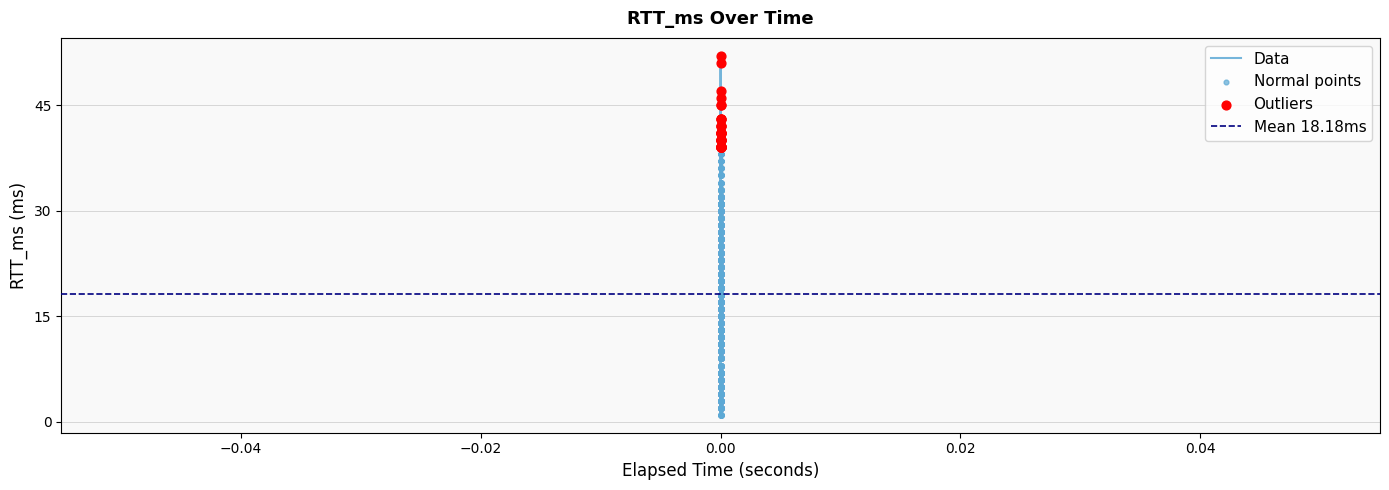

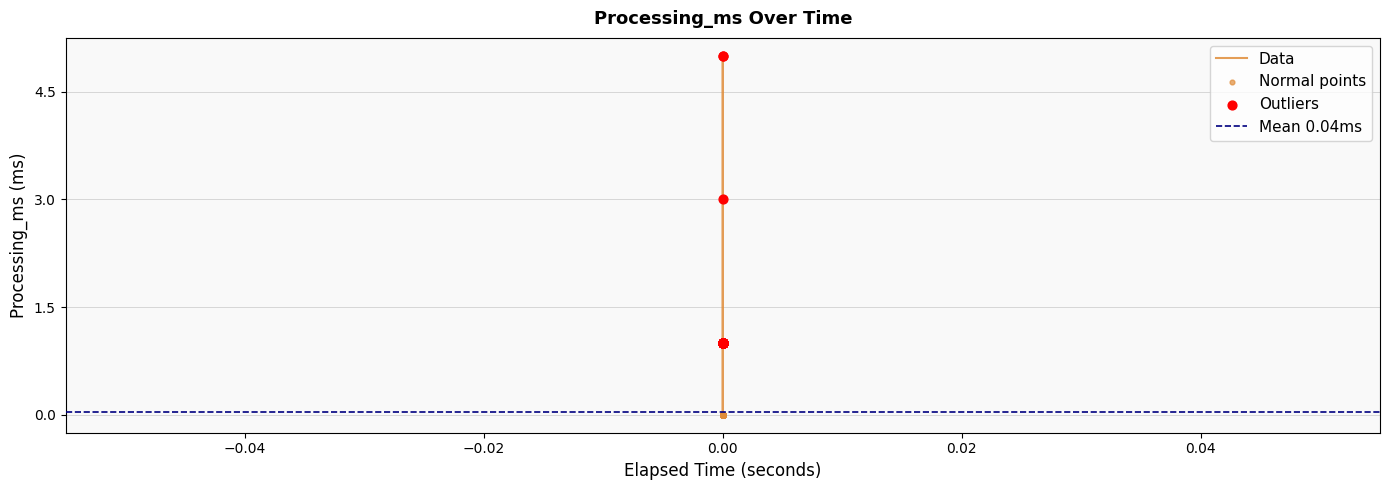

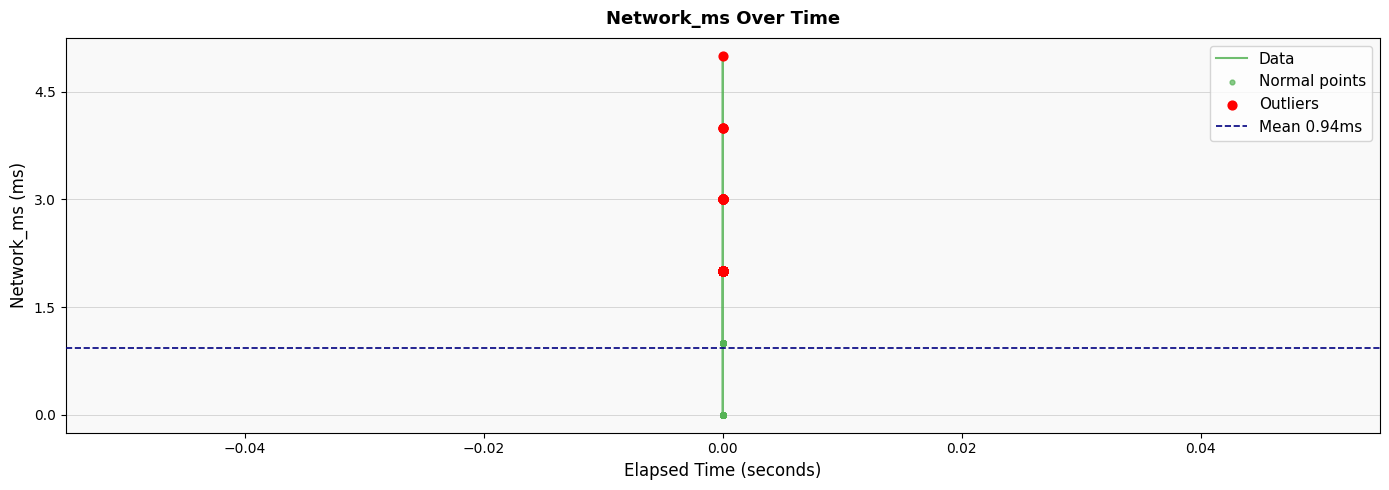

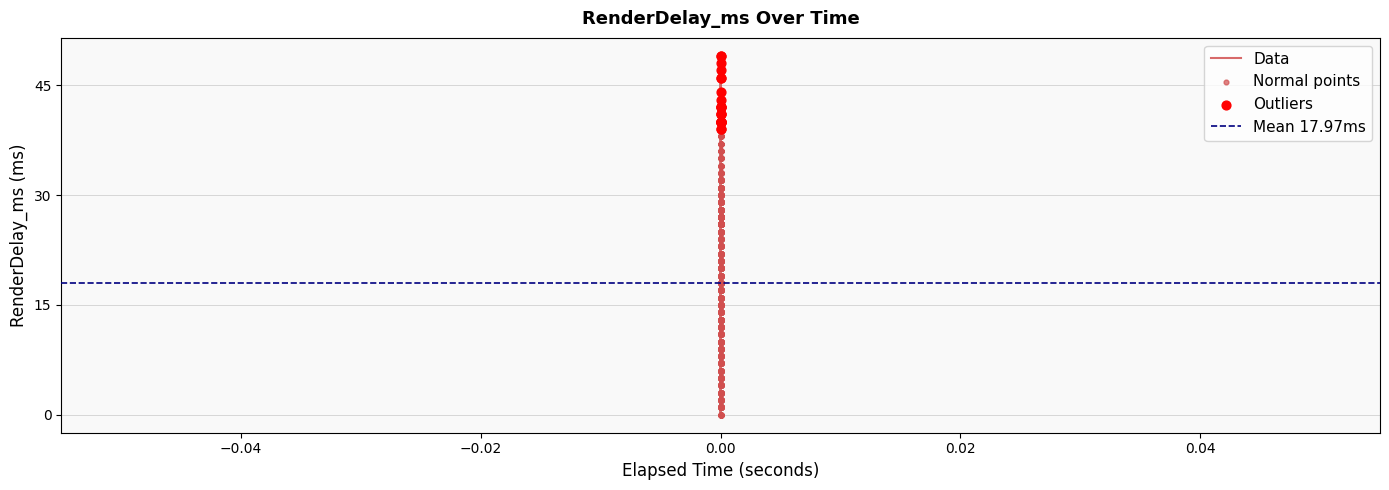

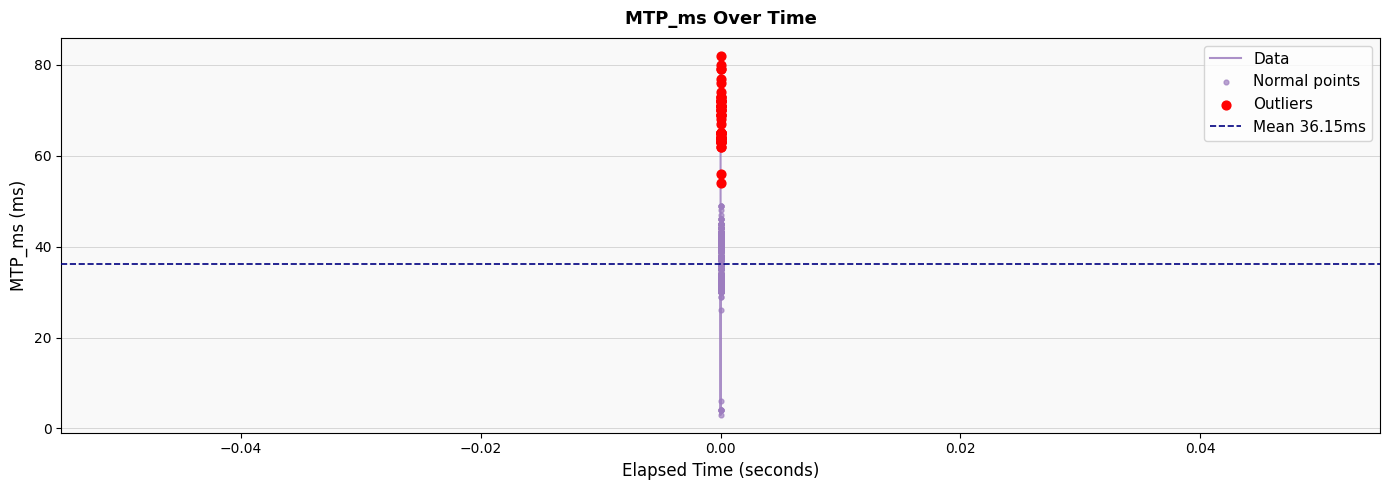

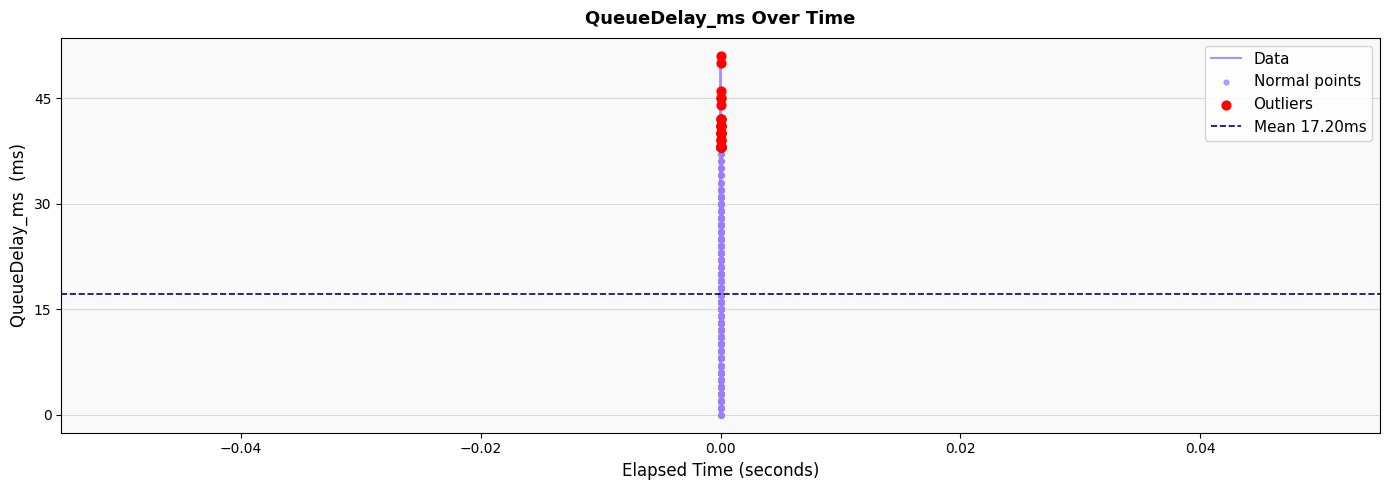

In [23]:
# ── Plot (Individual outputs for each metric) ──────────────────────
panels = [
    dict(col="RTT_ms",         label="RTT_ms (ms)",         color="#5da9d5", title="RTT_ms Over Time"),
    dict(col="Processing_ns",  label="Processing_ms (ms)",  color="#e08c39", title="Processing_ms Over Time"),
    dict(col="Network_ms",     label="Network_ms (ms)",     color="#56b356", title="Network_ms Over Time"),
    dict(col="RenderDelay_ms", label="RenderDelay_ms (ms)", color="#d14f4f", title="RenderDelay_ms Over Time"),
    dict(col="MTP_ms",         label="MTP_ms (ms)",         color="#9d7dbf", title="MTP_ms Over Time"),
    dict(col="QueueDelay_ms",  label="QueueDelay_ms  (ms)",         color="#9d7dff", title="QueueDelay_ms Over Time"),
]

x = df_clean["elapsed_s"].values

# Create separate figure for each metric
for p in panels:
    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

    y      = df_clean[p["col"]].values
    mean   = y.mean()
    std    = y.std()
    is_out = y > mean + OUTLIER_THRESHOLD * std

    # Main line
    ax.plot(x, y, color=p["color"], linewidth=1.5, alpha=0.85, zorder=2, label="Data")

    # Normal scatter points
    ax.scatter(x[~is_out], y[~is_out],
               color=p["color"], s=12, zorder=3, alpha=0.7, label="Normal points")

    # Outlier points in red
    if is_out.any():
        ax.scatter(x[is_out], y[is_out],
                   color="red", s=40, zorder=5, label="Outliers")

    # Mean dashed line
    ax.axhline(mean, color="navy", linewidth=1.2, linestyle="--", zorder=4, label=f"Mean {mean:.2f}ms")

    # Legend
    ax.legend(loc="upper right", fontsize=11, framealpha=0.8)

    ax.set_title(p["title"], fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Elapsed Time (seconds)", fontsize=12)
    ax.set_ylabel(p["label"], fontsize=12)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(axis="y", color="gray", linewidth=0.4, alpha=0.5)
    ax.set_facecolor("#f9f9f9")

    plt.tight_layout()
    plt.show()

# Also save combined plot for reference
# fig, axes = plt.subplots(len(panels), 1,
#                           figsize=(FIG_WIDTH, FIG_HEIGHT),
#                           sharex=True,
#                           constrained_layout=True)

# for ax, p in zip(axes, panels):
#     y      = df_clean[p["col"]].values
#     mean   = y.mean()
#     std    = y.std()
#     is_out = y > mean + OUTLIER_THRESHOLD * std

#     ax.plot(x, y, color=p["color"], linewidth=1.5, alpha=0.85, zorder=2)
#     ax.scatter(x[~is_out], y[~is_out], color=p["color"], s=12, zorder=3, alpha=0.7)

#     if is_out.any():
#         ax.scatter(x[is_out], y[is_out], color="red", s=40, zorder=5)

#     ax.axhline(mean, color="navy", linewidth=1.2, linestyle="--", zorder=4)
#     ax.legend([f"Mean {mean:.2f}ms"], loc="upper right", fontsize=10, framealpha=0.7, handlelength=1.5)
#     ax.set_title(p["title"], fontsize=12, fontweight="bold", pad=3)
#     ax.set_ylabel(p["label"], fontsize=10)
#     ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
#     ax.tick_params(axis="both", labelsize=9)
#     ax.grid(axis="y", color="gray", linewidth=0.3, alpha=0.5)
#     ax.set_facecolor("#f9f9f9")

# axes[-1].set_xlabel("Elapsed Time (seconds)", fontsize=11)
# fig.suptitle("Latency Metrics Over Time", fontsize=13, fontweight="bold", y=1.01)

# out_png = os.path.splitext(CSV_PATH)[0] + "_latency_plots.png"
# fig.savefig(out_png, dpi=DPI, bbox_inches="tight")
# print(f"Saved → {out_png}")

# plt.show()

/tmp/ipykernel_1701/2598181000.py:53: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


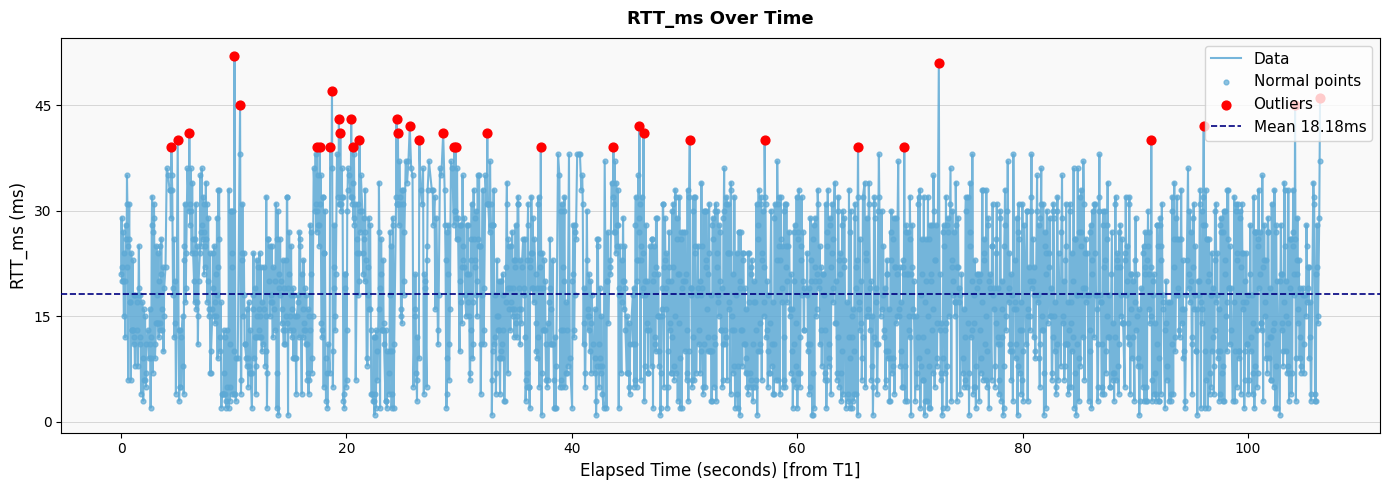

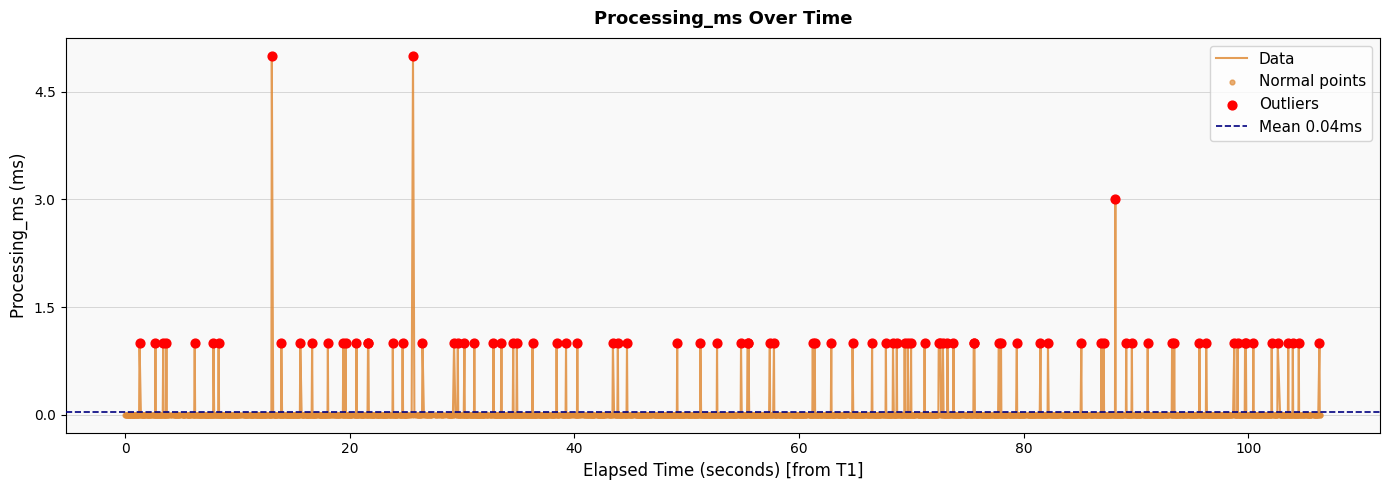

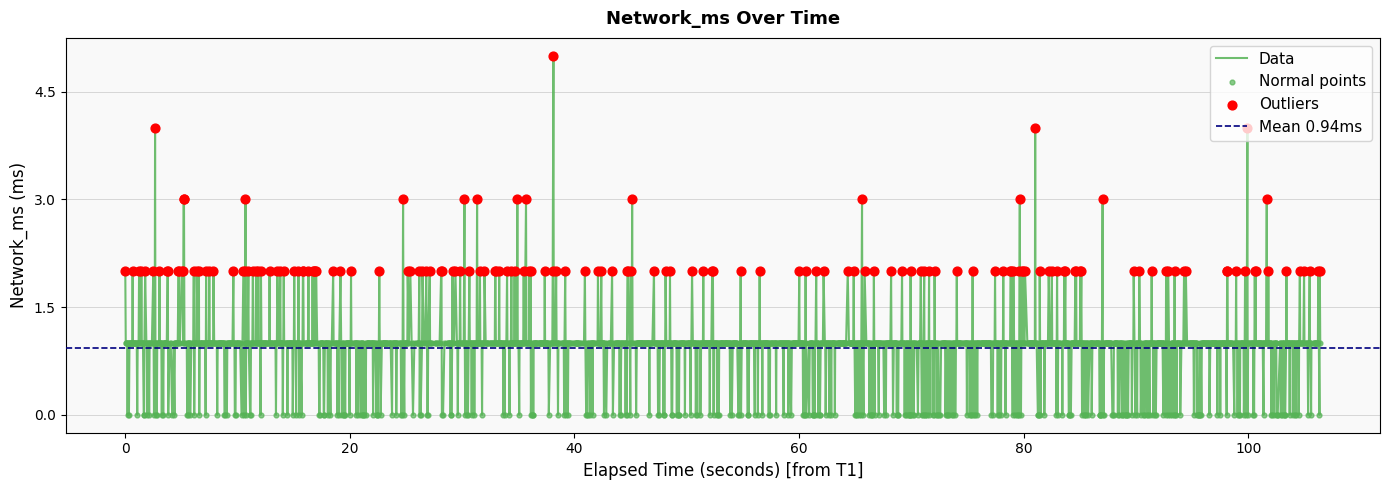

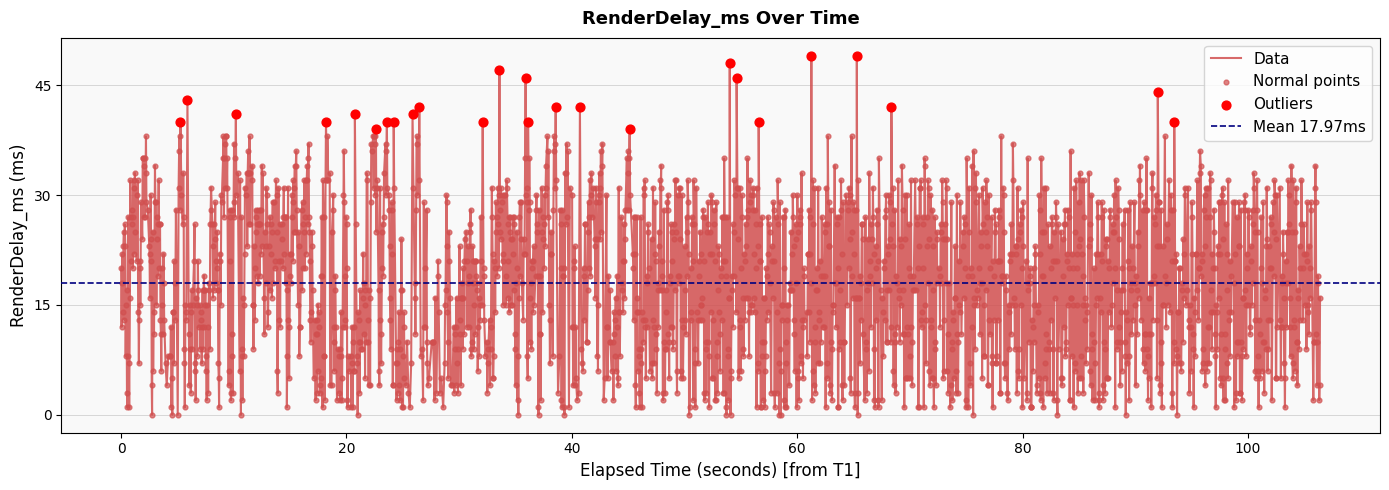

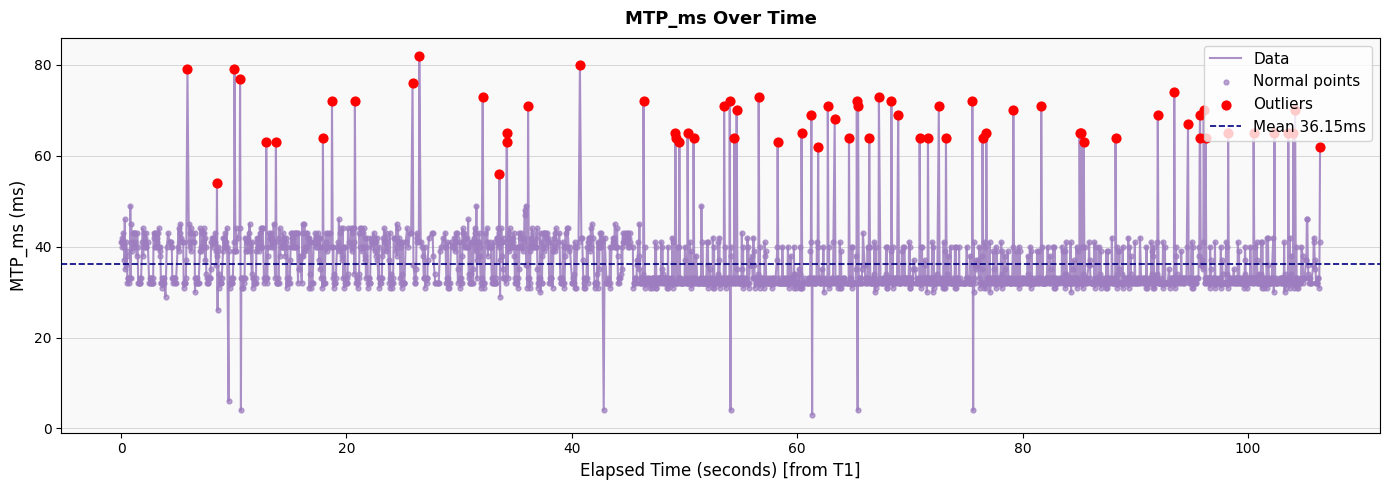

In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Plot (Individual outputs for each metric) ──────────────────────
panels = [
    dict(col="RTT_ms",         label="RTT_ms (ms)",         color="#5da9d5", title="RTT_ms Over Time"),
    dict(col="Processing_ns",  label="Processing_ms (ms)",  color="#e08c39", title="Processing_ms Over Time"),
    dict(col="Network_ms",     label="Network_ms (ms)",     color="#56b356", title="Network_ms Over Time"),
    dict(col="RenderDelay_ms", label="RenderDelay_ms (ms)", color="#d14f4f", title="RenderDelay_ms Over Time"),
    dict(col="MTP_ms",         label="MTP_ms (ms)",         color="#9d7dbf", title="MTP_ms Over Time"),
    # dict(col="QueueDelay_ms",  label="QueueDelay_ms  (ms)", color="#9d7dff", title="QueueDelay_ms Over Time"),
]

# Using T1_ms for the x-axis (elapsed time)
t1_start = df_clean["T1_ms"].iloc[0]
x = (df_clean["T1_ms"].values - t1_start) / 1000.0

# Create separate figure for each metric
for p in panels:
    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

    y      = df_clean[p["col"]].values
    mean   = y.mean()
    std    = y.std()
    is_out = y > mean + OUTLIER_THRESHOLD * std

    # Main line
    ax.plot(x, y, color=p["color"], linewidth=1.5, alpha=0.85, zorder=2, label="Data")

    # Normal scatter points
    ax.scatter(x[~is_out], y[~is_out],
               color=p["color"], s=12, zorder=3, alpha=0.7, label="Normal points")

    # Outlier points in red
    if is_out.any():
        ax.scatter(x[is_out], y[is_out],
                   color="red", s=40, zorder=5, label="Outliers")

    # Mean dashed line
    ax.axhline(mean, color="navy", linewidth=1.2, linestyle="--", zorder=4, label=f"Mean {mean:.2f}ms")

    # Legend
    ax.legend(loc="upper right", fontsize=11, framealpha=0.8)

    ax.set_title(p["title"], fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Elapsed Time (seconds) [from T1]", fontsize=12)
    ax.set_ylabel(p["label"], fontsize=12)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(axis="y", color="gray", linewidth=0.4, alpha=0.5)
    ax.set_facecolor("#f9f9f9")

    plt.tight_layout()
    plt.show()

In [25]:
# ── Summary statistics ────────────────────────────────────────────
stat_cols = ["RTT_ms", "Processing_ns", "Network_ms", "RenderDelay_ms", "MTP_ms"]
df_clean[stat_cols].describe().round(3)

,RTT_ms,Processing_ns,Network_ms,RenderDelay_ms,MTP_ms
count,2260.000,2260.000,2260.000,2260.000,2260.000
mean,18.180,0.044,0.935,17.969,36.149
std,10.028,0.250,0.497,10.093,7.216
min,1.000,0.000,0.000,0.000,3.000
25%,10.000,0.000,1.000,10.000,32.000
50%,18.000,0.000,1.000,18.000,33.000
75%,26.000,0.000,1.000,26.000,40.000
max,52.000,5.000,5.000,49.000,82.000


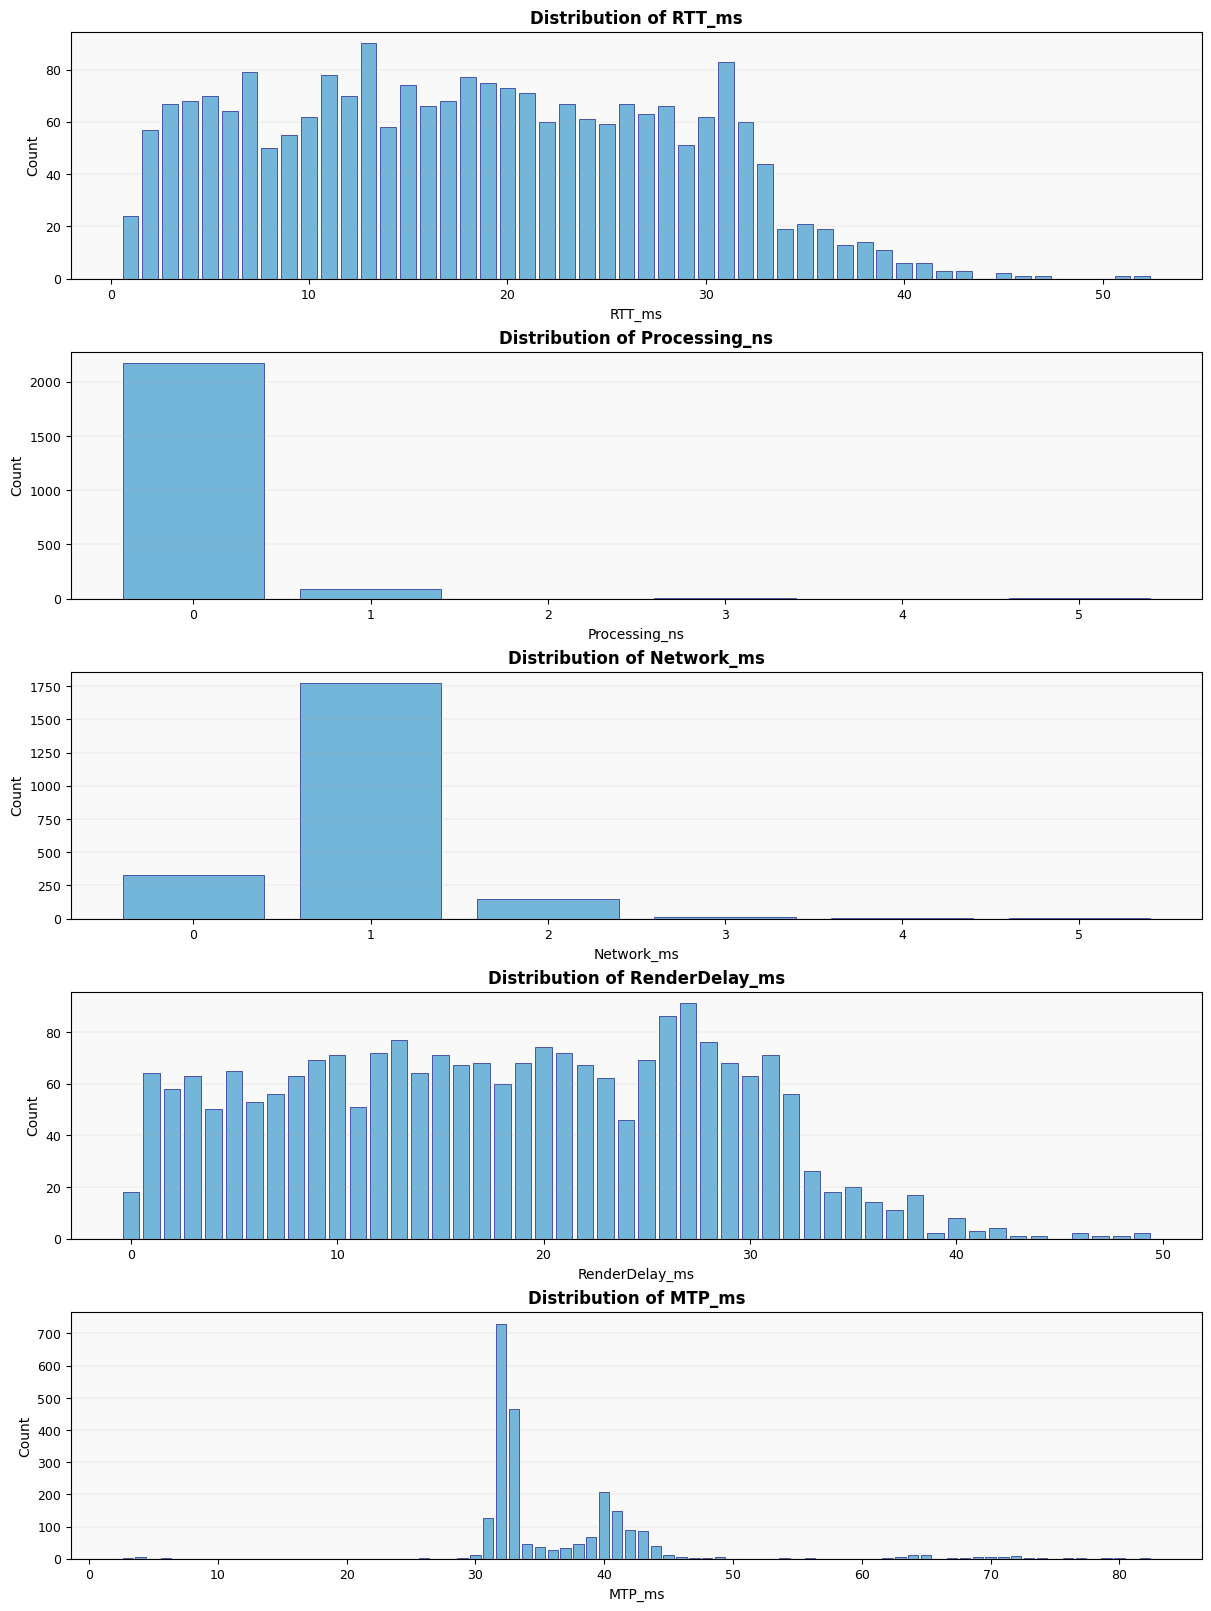


RTT_ms value counts (top 15):


,count
RTT_ms,
1,24
2,57
3,67
4,68
5,70
6,64
7,79
8,50
9,55



Processing_ns value counts (top 15):


,count
Processing_ns,
0,2170
1,87
3,1
5,2



Network_ms value counts (top 15):


,count
Network_ms,
0,329
1,1770
2,144
3,13
4,3
5,1



RenderDelay_ms value counts (top 15):


,count
RenderDelay_ms,
0,18
1,64
2,58
3,63
4,50
5,65
6,53
7,56
8,63



MTP_ms value counts (top 15):


,count
MTP_ms,
3,1
4,5
6,1
26,1
29,2
30,11
31,126
32,731
33,464


In [26]:
# Distribution histogram (count of each value) for all latency metrics
fig, axes = plt.subplots(len(stat_cols), 1, figsize=(12, 16), constrained_layout=True)

value_counts_by_metric = {}

for ax, col in zip(axes, stat_cols):
    s = df_clean[col].copy()

    # Processing_ms is continuous; round slightly so the distribution is readable
    if col == "Processing_ms":
        s = s.round(3)

    counts = s.value_counts().sort_index()
    value_counts_by_metric[col] = counts

    ax.bar(counts.index, counts.values, color="#5da9d5", alpha=0.85, width=0.8, edgecolor="navy", linewidth=0.5)
    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.tick_params(axis="both", labelsize=9)
    ax.grid(axis="y", linewidth=0.3, alpha=0.5)
    ax.set_facecolor("#f9f9f9")

plt.show()

# Optional: frequency tables (value -> count) for each metric
for col in stat_cols:
    print(f"\n{col} value counts (top 15):")
    display(value_counts_by_metric[col].head(15))

/tmp/ipykernel_1701/1377685427.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


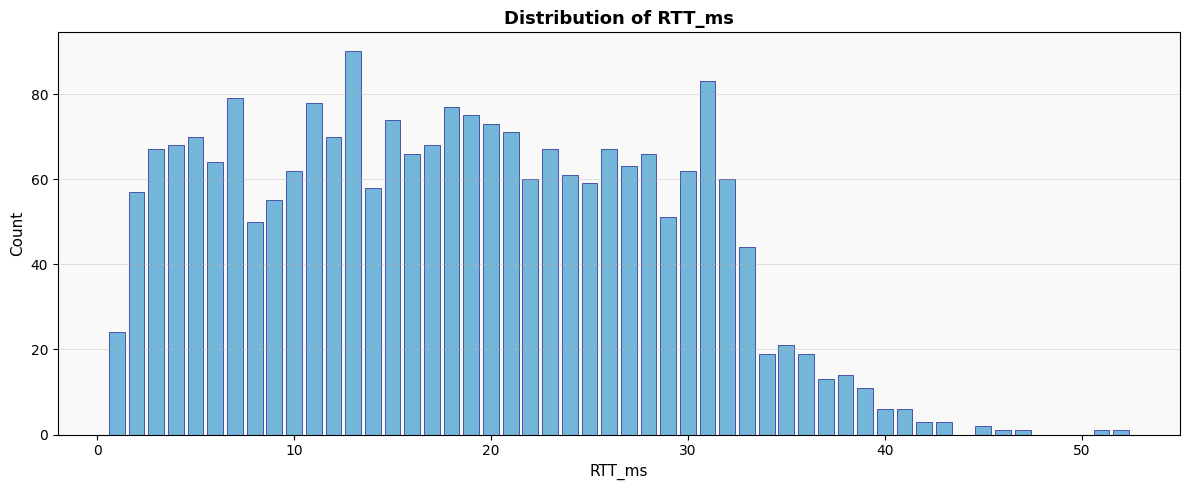

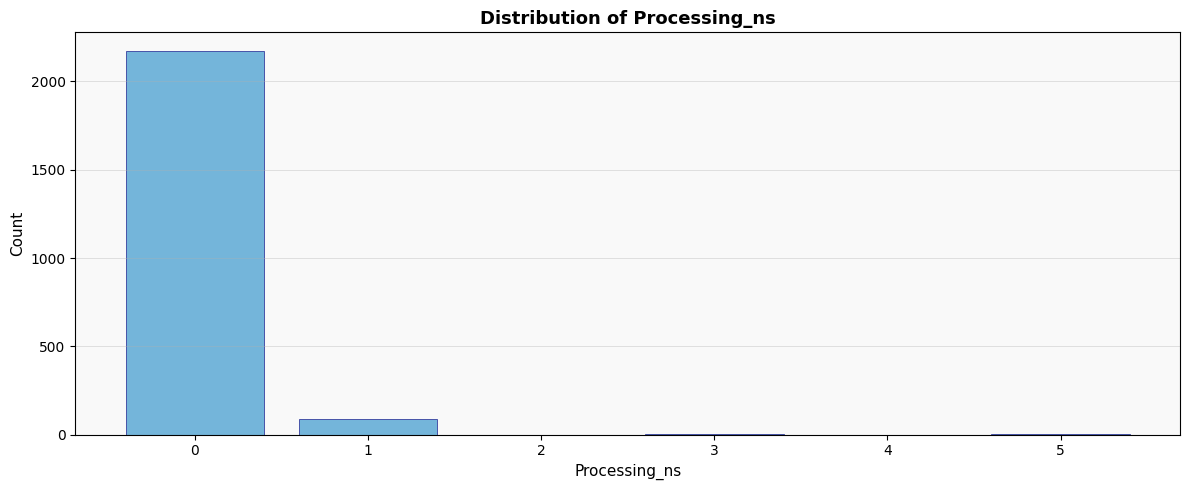

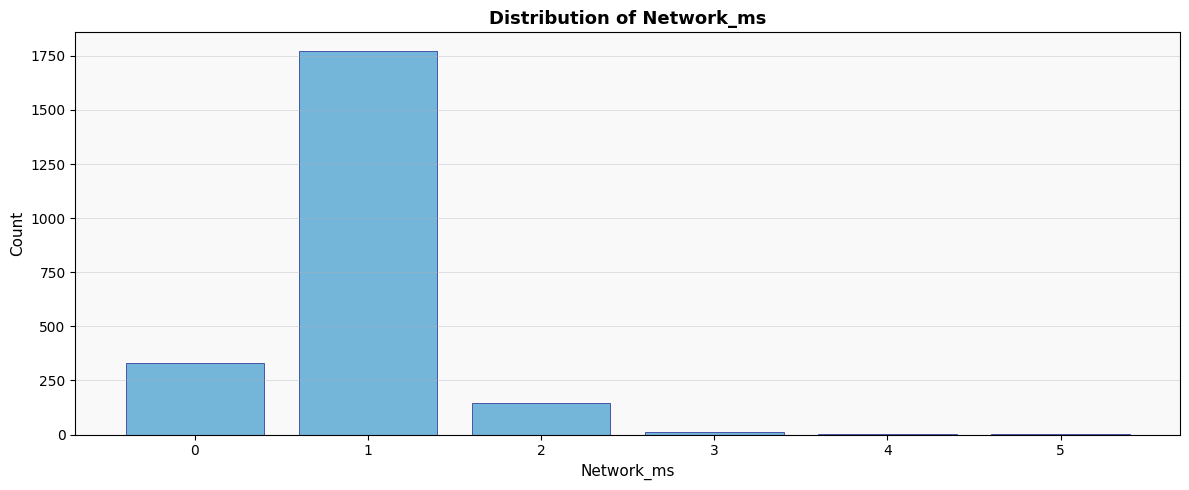

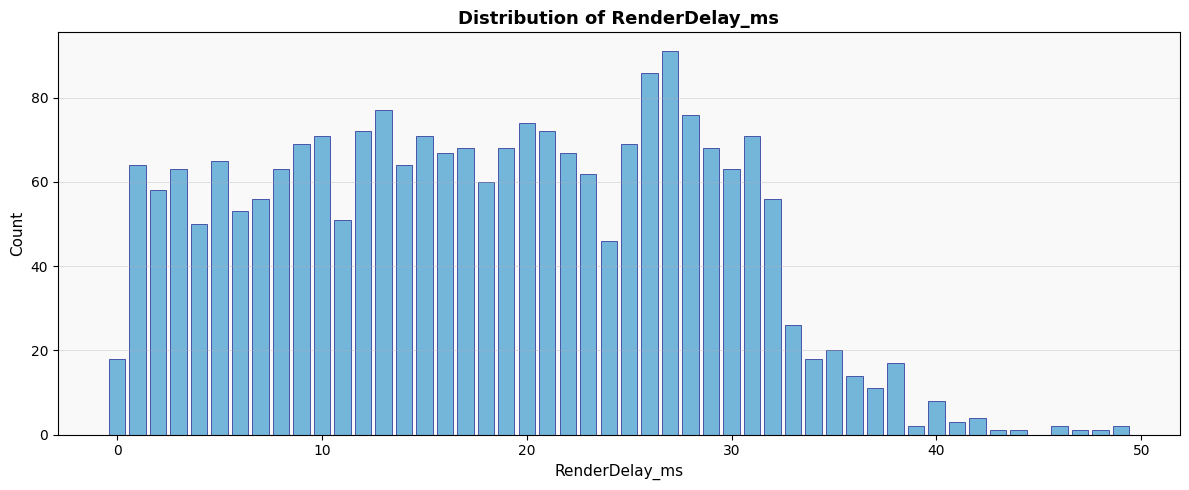

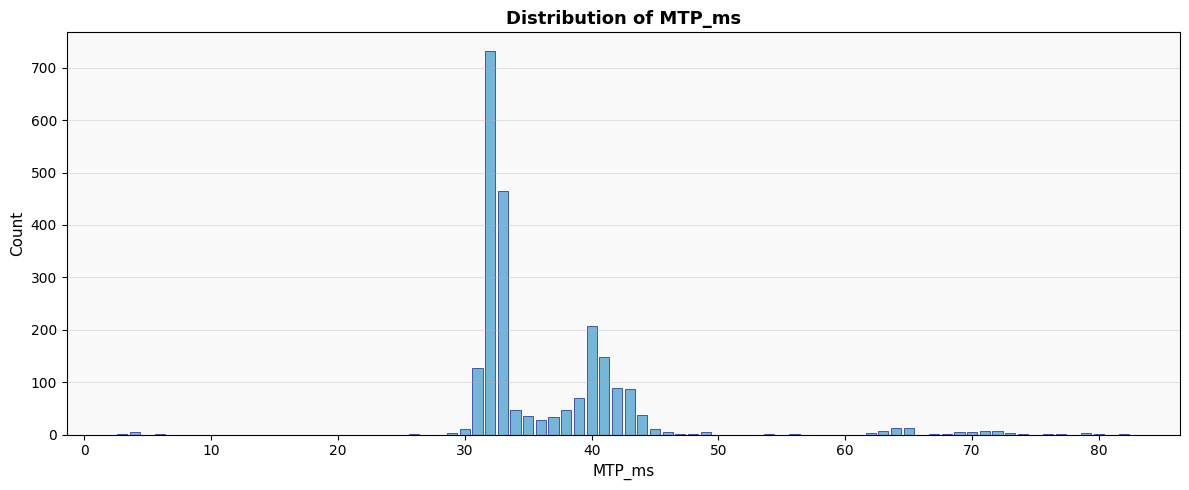

In [27]:
# ── Individual Distribution Plots (One per cell output) ──────────
for col in stat_cols:
    fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

    s = df_clean[col].copy()

    # Processing_ms is continuous; round slightly so the distribution is readable
    if col == "Processing_ms":
        s = s.round(3)

    counts = s.value_counts().sort_index()

    ax.bar(counts.index, counts.values, color="#5da9d5", alpha=0.85, width=0.8, edgecolor="navy", linewidth=0.5)
    ax.set_title(f"Distribution of {col}", fontsize=13, fontweight="bold")
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(axis="y", linewidth=0.5, alpha=0.5)
    ax.set_facecolor("#f9f9f9")

    plt.tight_layout()
    plt.show()

In [28]:
# Percentage of missing cmd_seq from the CSV (based on sequence gaps)
if "cmd_seq_echo" not in df.columns:
    print("Column 'cmd_seq_echo' not found in CSV.")
else:
    cmd = pd.to_numeric(df["cmd_seq_echo"], errors="coerce").dropna().astype(int)

    if cmd.empty:
        print("No valid cmd_seq_echo values found.")
    else:
        observed = set(cmd.unique())
        expected = set(range(cmd.min(), cmd.max() + 1))
        missing = expected - observed

        missing_count = len(missing)
        expected_count = len(expected)
        missing_pct = (missing_count / expected_count) * 100 if expected_count else 0.0

        print(f"cmd_seq range      : {cmd.min()} to {cmd.max()}")
        print(f"Expected seq count : {expected_count}")
        print(f"Observed seq count : {len(observed)}")
        print(f"Missing seq count  : {missing_count}")
        print(f"Missing percentage : {missing_pct:.2f}%")

        # Optional: show first few missing sequence numbers
        if missing_count:
            print("First missing cmd_seq values:", sorted(missing)[:20])

# Optional: percentage of null/blank cmd_seq cells in CSV
null_pct = df["cmd_seq"].isna().mean() * 100 if "cmd_seq" in df.columns else np.nan
print(f"Null cmd_seq cell percentage: {null_pct:.2f}%")

cmd_seq range      : 2 to 3024
Expected seq count : 3023
Observed seq count : 2260
Missing seq count  : 763
Missing percentage : 25.24%
First missing cmd_seq values: [17, 22, 36, 37, 44, 48, 50, 51, 62, 63, 65, 66, 70, 76, 81, 97, 101, 105, 106, 108]
Null cmd_seq cell percentage: nan%


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# ── Configuration ──────────────────────────────────────────────────
CSV_PATH = "/content/drive/MyDrive/Capstone project/final/isaac_tcp_packet_log_20260524_001451.csv"   # adjust path if needed
# ── Load data ──────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows  |  columns: {list(df.columns)}")
df.head(3)

Loaded 3026 rows  |  columns: ['t3_recv', 'tq_dequeue', 'cmd_seq', 't0', 't1', 'action_type', 'action_data']


,t3_recv,tq_dequeue,cmd_seq,t0,t1,action_type,action_data
0,1779561909845,1779561909868,1,1779561909829,1779561909829,delta,"0,0.05"
1,1779561909849,1779561909868,2,1779561909829,1779561909834,delta,"0,0.05"
2,1779561909890,1779561909918,3,1779561909829,1779561909875,delta,"0,0.05"


In [30]:
# Percentage of missing cmd_seq from the CSV (based on sequence gaps)
if "cmd_seq" not in df.columns:
    print("Column 'cmd_seq' not found in CSV.")
else:
    cmd = pd.to_numeric(df["cmd_seq"], errors="coerce").dropna().astype(int)

    if cmd.empty:
        print("No valid cmd_seq values found.")
    else:
        observed = set(cmd.unique())
        expected = set(range(cmd.min(), cmd.max() + 1))
        missing = expected - observed

        missing_count = len(missing)
        expected_count = len(expected)
        missing_pct = (missing_count / expected_count) * 100 if expected_count else 0.0

        print(f"cmd_seq range      : {cmd.min()} to {cmd.max()}")
        print(f"Expected seq count : {expected_count}")
        print(f"Observed seq count : {len(observed)}")
        print(f"Missing seq count  : {missing_count}")
        print(f"Missing percentage : {missing_pct:.2f}%")

        # Optional: show first few missing sequence numbers
        if missing_count:
            print("First missing cmd_seq values:", sorted(missing)[:20])

# Optional: percentage of null/blank cmd_seq cells in CSV
null_pct = df["cmd_seq"].isna().mean() * 100 if "cmd_seq" in df.columns else np.nan
print(f"Null cmd_seq cell percentage: {null_pct:.2f}%")

cmd_seq range      : 1 to 3026
Expected seq count : 3026
Observed seq count : 3026
Missing seq count  : 0
Missing percentage : 0.00%
Null cmd_seq cell percentage: 0.00%


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# ── Configuration ──────────────────────────────────────────────────
CSV_PATH = "/content/drive/MyDrive/Capstone project/final/unity_packet_log_20260523_184455.csv"   # adjust path if needed
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows  |  columns: {list(df.columns)}")
df.head(3)

Loaded 2865 rows  |  columns: ['utc_iso', 'unix_ms', 'seq', 'cmd_seq_echo', 't0_echo', 't1_echo', 't3_recv', 'tq_dequeue', 't4_physics', 't5_send', 't6_unity']


,utc_iso,unix_ms,seq,cmd_seq_echo,t0_echo,t1_echo,t3_recv,tq_dequeue,t4_physics,t5_send,t6_unity
0,2026-05-23T18:44:59.5667520Z,1779561899566,1,0,0,0,0,0,1779561899569,1779561899569,1779561899555
1,2026-05-23T18:44:59.5986170Z,1779561899598,2,0,0,0,0,0,1779561899601,1779561899602,1779561899588
2,2026-05-23T18:44:59.6305630Z,1779561899630,3,0,0,0,0,0,1779561899639,1779561899639,1779561899625


In [32]:
# Percentage of missing cmd_seq from the CSV (based on sequence gaps)
print("Without Emulation")
if "seq" not in df.columns:
    print("Column 'cmd_seq' not found in CSV.")
else:
    cmd = pd.to_numeric(df["seq"], errors="coerce").dropna().astype(int)

    if cmd.empty:
        print("No valid cmd_seq values found.")
    else:
        observed = set(cmd.unique())
        expected = set(range(cmd.min(), cmd.max() + 1))
        missing = expected - observed

        missing_count = len(missing)
        expected_count = len(expected)
        missing_pct = (missing_count / expected_count) * 100 if expected_count else 0.0

        print(f"cmd_seq range      : {cmd.min()} to {cmd.max()}")
        print(f"Expected seq count : {expected_count}")
        print(f"Observed seq count : {len(observed)}")
        print(f"Missing seq count  : {missing_count}")
        print(f"Missing percentage : {missing_pct:.2f}%")

        # Optional: show first few missing sequence numbers
        if missing_count:
            print("First missing cmd_seq values:", sorted(missing)[:20])

# Optional: percentage of null/blank cmd_seq cells in CSV
null_pct = df["cmd_seq"].isna().mean() * 100 if "cmd_seq" in df.columns else np.nan
print(f"Null cmd_seq cell percentage: {null_pct:.2f}%")

Without Emulation
cmd_seq range      : 1 to 2865
Expected seq count : 2865
Observed seq count : 2865
Missing seq count  : 0
Missing percentage : 0.00%
Null cmd_seq cell percentage: nan%


In [33]:
stat_cols = ["RTT_ms", "Processing_ns", "Network_ms", "RenderDelay_ms", "MTP_ms"]

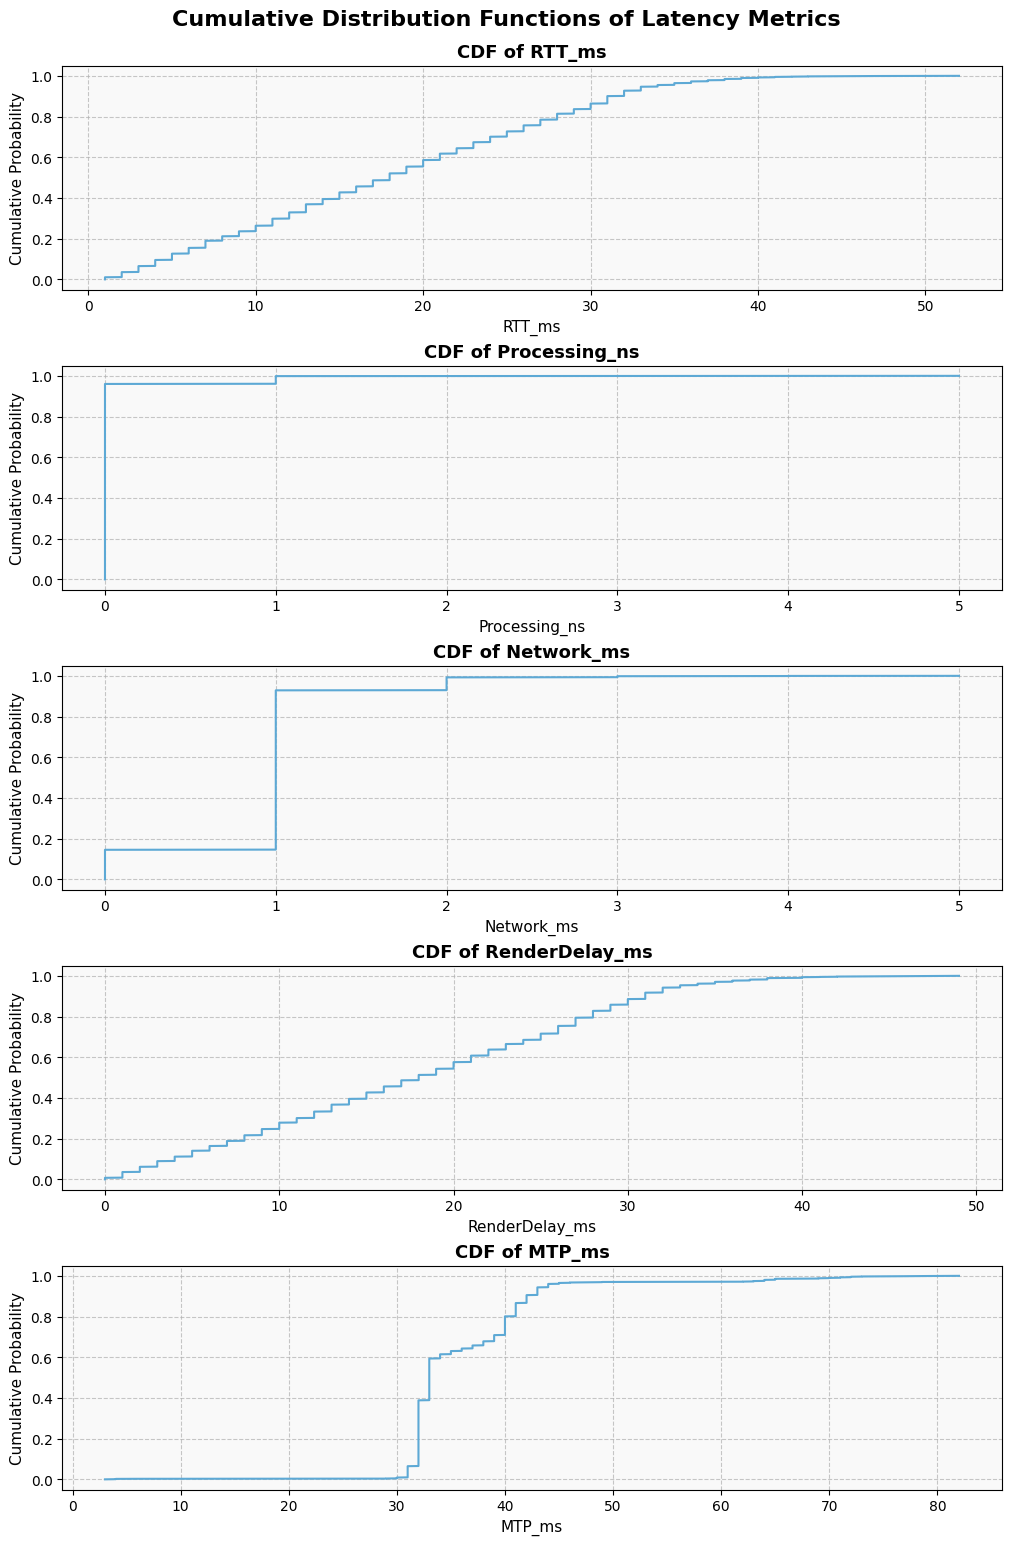

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(stat_cols), 1, figsize=(10, 15), constrained_layout=True)

for i, col in enumerate(stat_cols):
    ax = axes[i]

    # Get data and drop NaNs
    data = df_clean[col].dropna()

    # Sort the data
    sorted_data = np.sort(data)

    # Calculate CDF
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

    # Plot CDF
    ax.plot(sorted_data, cdf, color='#5da9d5', linewidth=1.5)

    ax.set_title(f"CDF of {col}", fontsize=13, fontweight="bold")
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Cumulative Probability", fontsize=11)
    ax.grid(axis="both", linestyle='--', alpha=0.7)
    ax.set_facecolor("#f9f9f9")
    ax.tick_params(axis="both", labelsize=10)

plt.suptitle("Cumulative Distribution Functions of Latency Metrics", fontsize=16, fontweight="bold", y=1.02)
plt.show()

In [38]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import os
# #Network_ms
# def load_and_preprocess_latency_data(csv_path):
#     """Loads a latency CSV, cleans it, and pre-processes columns."""
#     df = pd.read_csv(csv_path)

#     # Drop the first row if it is the warm-up / outlier spike
#     # (RTT > 1 000 ms means it is the very first connection packet)
#     df_clean = df[df["RTT_ms"] < 1_000].copy().reset_index(drop=True)

#     # Elapsed time in seconds (relative to first clean packet)
#     t0 = df_clean["T0_ms"].iloc[0]
#     df_clean["elapsed_s"] = (df_clean["T0_ms"] - t0) / 1_000.0

#     # Convert Processing from ns → ms
#     df_clean["Processing_ms"] = df_clean["Processing_ns"] / 1_000_000.0
#     return df_clean

# # --- User Input Required ---
# # Please specify the metric you want to plot
# # (e.g., "RTT_ms", "Processing_ms", "Network_ms", "RenderDelay_ms", "MTP_ms")
# metric_to_plot = "RTT_ms"

# # Please provide the paths to the three CSV files you want to compare.
# # These files should contain the specified metric (e.g., latency log files).
# # Update these paths with your actual file locations.
# csv_paths_for_comparison = [
#     "/content/drive/MyDrive/Teleoperation experiments/linuxMachine/same machine/exp1/latency_log_20260402_140319.csv",
#     "/content/drive/MyDrive/Teleoperation experiments/linuxMachine/different Machine/exp3_Apr7_00:05 /latency_log_20260406_182121.csv", # Placeholder: replace with your second file path
#     "/content/drive/MyDrive/Teleoperation experiments/udp/Without emulation/latency_log_20260320_061137.csv"  # Placeholder: replace with your third file path
# ]

# # Validate that three paths are provided
# if len(csv_paths_for_comparison) != 3:
#     raise ValueError("Please provide exactly three CSV file paths for comparison in 'csv_paths_for_comparison'.")

# plt.figure(figsize=(10, 6))

# for i, path in enumerate(csv_paths_for_comparison):
#     print(f"Processing file: {os.path.basename(path)}")
#     try:
#         df_current = load_and_preprocess_latency_data(path)

#         if metric_to_plot not in df_current.columns:
#             print(f"Warning: Metric '{metric_to_plot}' not found in {os.path.basename(path)}. Skipping this file.")
#             continue

#         data = df_current[metric_to_plot].dropna()
#         sorted_data = np.sort(data)
#         cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

#         label = f"File {i+1}: {os.path.basename(path)}" # Use a more distinct label
#         plt.plot(sorted_data, cdf, label=label, linewidth=1.5)
#     except FileNotFoundError:
#         print(f"Error: File not found at {path}. Please check the path.")
#     except Exception as e:
#         print(f"An error occurred processing {os.path.basename(path)}: {e}")

# plt.title(f"Cumulative Distribution Function of {metric_to_plot}", fontsize=16, fontweight="bold")
# plt.xlabel(metric_to_plot, fontsize=12)
# plt.ylabel("Cumulative Probability", fontsize=12)
# plt.grid(axis="both", linestyle='--', alpha=0.7)
# plt.legend(loc="lower right", fontsize=10)
# plt.gca().set_facecolor("#f9f9f9")
# plt.tick_params(axis="both", labelsize=10)
# plt.tight_layout()
# plt.show()

In [39]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import os

# def load_and_preprocess_latency_data(csv_path):
#     """Loads a latency CSV, cleans it, and pre-processes columns."""
#     df = pd.read_csv(csv_path)

#     # Drop the first row if it is the warm-up / outlier spike
#     # (RTT > 1 000 ms means it is the very first connection packet)
#     df_clean = df[df["RTT_ms"] < 1_000].copy().reset_index(drop=True)

#     # Elapsed time in seconds (relative to first clean packet)
#     t0 = df_clean["T0_ms"].iloc[0]
#     df_clean["elapsed_s"] = (df_clean["T0_ms"] - t0) / 1_000.0

#     # Convert Processing from ns → ms
#     df_clean["Processing_ms"] = df_clean["Processing_ns"] / 1_000_000.0
#     return df_clean

# # --- User Input Required ---
# # Please specify the metric you want to plot
# # (e.g., "RTT_ms", "Processing_ms", "Network_ms", "RenderDelay_ms", "MTP_ms")
# metric_to_plot = "MTP_ms"

# # Define the paths and their desired labels
# file_labels = {
#     "/content/drive/MyDrive/Teleoperation experiments/linuxMachine/same machine/exp1/latency_log_20260402_140319.csv": "same machine",
#     "/content/drive/MyDrive/Teleoperation experiments/linuxMachine/different Machine/exp3_Apr7_00:05 /latency_log_20260406_182121.csv": "different Machine",
#     "/content/drive/MyDrive/Teleoperation experiments/udp/Without emulation/latency_log_20260320_061137.csv": "udp"
# }

# csv_paths_for_comparison = list(file_labels.keys())

# # Validate that three paths are provided
# if len(csv_paths_for_comparison) != 3:
#     raise ValueError("Please provide exactly three CSV file paths for comparison in 'file_labels'.")

# plt.figure(figsize=(10, 6))

# for path in csv_paths_for_comparison:
#     print(f"Processing file: {os.path.basename(path)}")
#     try:
#         df_current = load_and_preprocess_latency_data(path)

#         if metric_to_plot not in df_current.columns:
#             print(f"Warning: Metric '{metric_to_plot}' not found in {os.path.basename(path)}. Skipping this file.")
#             continue

#         data = df_current[metric_to_plot].dropna()
#         sorted_data = np.sort(data)
#         cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

#         label = file_labels[path] # Use the custom label
#         plt.plot(sorted_data, cdf, label=label, linewidth=1.5)
#     except FileNotFoundError:
#         print(f"Error: File not found at {path}. Please check the path.")
#     except Exception as e:
#         print(f"An error occurred processing {os.path.basename(path)}: {e}")

# plt.title(f"Cumulative Distribution Function of {metric_to_plot}", fontsize=16, fontweight="bold")
# plt.xlabel(metric_to_plot, fontsize=12)
# plt.ylabel("Cumulative Probability", fontsize=12)
# plt.grid(axis="both", linestyle='--', alpha=0.7)
# plt.legend(loc="lower right", fontsize=10)
# plt.gca().set_facecolor("#f9f9f9")
# plt.tick_params(axis="both", labelsize=10)
# plt.tight_layout()
# plt.show()

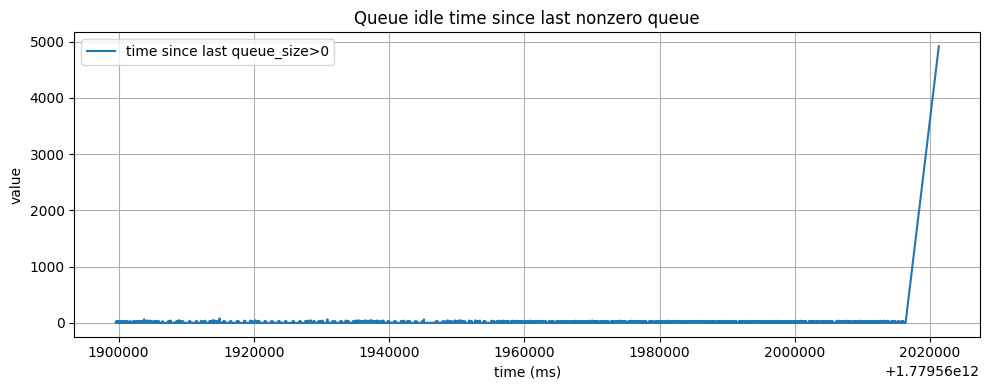

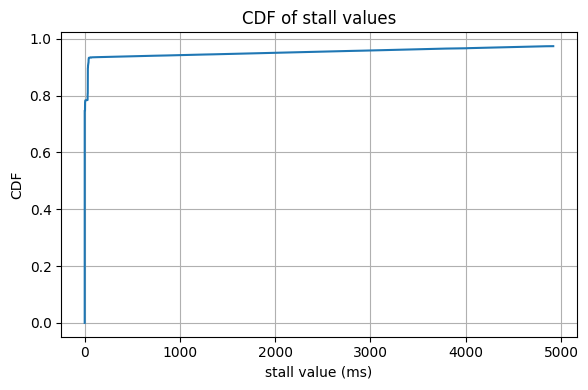

In [40]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Load the attached log file
log_path = "/content/drive/MyDrive/Capstone project/final/received_queue_size_log_20260523_184455.csv"
df = pd.read_csv(log_path)

# Map CSV columns to expected names
ts_col = "unix_ms"
queue_col = "received_queue_size"
if ts_col not in df.columns:
    raise ValueError(f"Missing timestamp column: {ts_col}")
if queue_col not in df.columns:
    raise ValueError(f"Missing queue size column: {queue_col}")

df = df.sort_values(ts_col).reset_index(drop=True)

# Compute last time when queue_size > 0, then diff
mask = df[queue_col] > 0
last_nonzero_time = df[ts_col].where(mask).ffill()
diff = df[ts_col] - last_nonzero_time

# Plot: 0 if queue_size > 0 else diff
y = np.where(mask, 0, diff)

plt.figure(figsize=(10, 4))
plt.plot(df[ts_col], y, label="time since last queue_size>0")
plt.xlabel("time (ms)")
plt.ylabel("value")
plt.title("Queue idle time since last nonzero queue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# CDF of stall values (including zeros)
stall_values = y
if stall_values.size == 0:
    print("No stall values to plot CDF.")
else:
    x = np.sort(stall_values)
    cdf = np.arange(1, x.size + 1) / x.size
    plt.figure(figsize=(6, 4))
    plt.plot(x, cdf, label="CDF of stall values")
    plt.xlabel("stall value (ms)")
    plt.ylabel("CDF")
    plt.title("CDF of stall values")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [41]:
import numpy as np
import pandas as pd

# Load the packet log (update log_path to your actual file)
log_path = "/content/drive/MyDrive/Capstone project/final/unity_packet_log_20260523_184455.csv"
df = pd.read_csv(log_path)

# Map the column names if needed. Based on the screenshot, columns are lowercase with suffixes
# e.g., t0_echo, t1_echo, t3_recv, tq_dequeue, t4_physics, t6_unity, t7_ms/t7_render
col_t1 = next((c for c in df.columns if c.startswith("t1")), "t1_echo")
col_t0 = next((c for c in df.columns if c.startswith("t0")), "t0_echo")
col_t3 = next((c for c in df.columns if c.startswith("t3")), "t3_recv")
col_tq = next((c for c in df.columns if c.startswith("tq")), "tq_dequeue")
col_t4 = next((c for c in df.columns if c.startswith("t4")), "t4_physics")
col_t6 = next((c for c in df.columns if c.startswith("t6")), "t6_unity")
col_t7 = next((c for c in df.columns if "t7" in c), "t7")

# The columns we want to forward fill when they have zero values
ffill_cols = [c for c in [col_t0, col_t1, col_t3, col_tq] if c in df.columns]

# Replace zeros with NaNs so pandas can forward fill them
for col in ffill_cols:
    df[col] = df[col].replace(0, np.nan)

# Ensure the t1 column exists
if col_t1 in df.columns:
    # Find the index of the first non-zero (non-NaN) value in T1
    first_valid_index = df[col_t1].first_valid_index()

    if first_valid_index is not None:
        # Start dataframe from the first valid T1 row
        df = df.loc[first_valid_index:].copy()

        # Forward fill the remaining NaNs (zeros) with the last non-zero value
        df[ffill_cols] = df[ffill_cols].ffill()

        # Calculate RTT_ms
        df["RTT_ms"] = (df[col_t6] - df[col_t1]).clip(lower=0)

        # Calculate Processing_ns
        if col_t4 in df.columns and col_tq in df.columns:
            df["Processing_ns"] = (df[col_t4] - df[col_tq]).clip(lower=0)

        # Calculate QueueDelay_ms
        if col_tq in df.columns and col_t3 in df.columns:
            df["QueueDelay_ms"] = (df[col_tq] - df[col_t3]).clip(lower=0)

        # Calculate Network_ms
        if all(c in df.columns for c in ["RTT_ms", "Processing_ns", "QueueDelay_ms"]):
            # Note: Processing_ns is in nanoseconds, while RTT and QueueDelay might be in ms.
            # If so, you need to divide Processing_ns by 1,000,000 to convert to ms before subtracting!
            df["Network_ms"] = (df["RTT_ms"] - (df["Processing_ns"] / 1000000.0) - df["QueueDelay_ms"]).clip(lower=0)

        # Calculate RenderDelay_ms
        if col_t7 in df.columns and col_t6 in df.columns:
            df["RenderDelay_ms"] = (df[col_t7] - df[col_t6]).clip(lower=0)

        # Calculate Jitter_ms (absolute difference between consecutive RTTs)
        if "RTT_ms" in df.columns:
            df["Jitter_ms"] = df["RTT_ms"].diff().abs().fillna(0)

        print(f"Calculations complete! Total rows calculated: {len(df)}")
        cols_to_show = [c for c in ["RTT_ms", "Processing_ns", "QueueDelay_ms", "Network_ms", "RenderDelay_ms", "Jitter_ms"] if c in df.columns]

        # Remove .head() to see all rows (or use it just to preview)
        display(df[cols_to_show])
    else:
        print(f"No non-zero value found in {col_t1} column.")
else:
    print(f"Column {col_t1} not found in the dataframe.")

Calculations complete! Total rows calculated: 2611


,RTT_ms,Processing_ns,QueueDelay_ms,Network_ms,Jitter_ms
254,21.0,0.0,19.0,2.000000,0.0
255,29.0,0.0,28.0,1.000000,8.0
256,22.0,0.0,21.0,1.000000,7.0
257,20.0,0.0,19.0,1.000000,2.0
258,27.0,0.0,26.0,1.000000,7.0
...,...,...,...,...,...
2860,29.0,1.0,28.0,0.999999,41.0
2861,37.0,0.0,35.0,2.000000,8.0
2862,46.0,0.0,45.0,1.000000,9.0
2863,15.0,0.0,15.0,0.000000,31.0


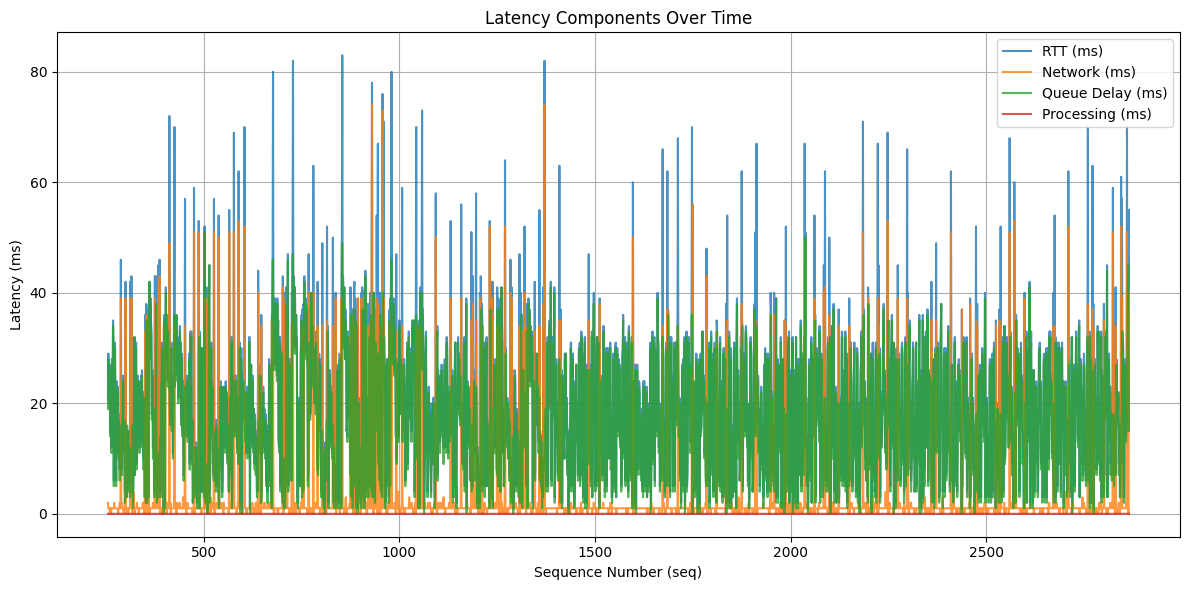

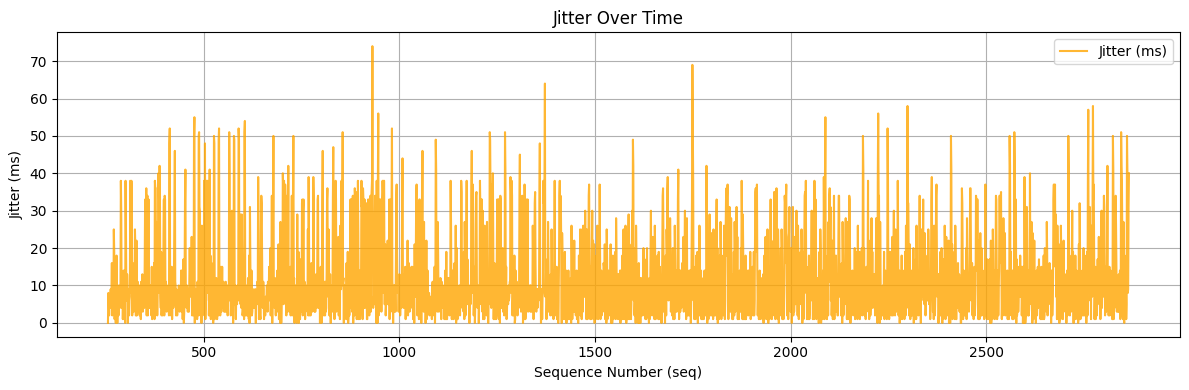

In [42]:
import matplotlib.pyplot as plt

# The dataframe 'df' is stored in the notebook's active memory as long as the kernel is running.
# Optionally, you can also save these new calculations back to a CSV on your disk:
# df.to_csv("processed_latency_log.csv", index=False)

if "RTT_ms" in df.columns:
    # Convert Processing_ns to Processing_ms just for easier plotting alongside other ms metrics
    if "Processing_ns" in df.columns and "Processing_ms" not in df.columns:
        df["Processing_ms"] = df["Processing_ns"] / 1000000.0

    # Determine a good X-axis (if 'seq' or 'cmd_seq_echo' exists, use it, else use the row index)
    if 'seq' in df.columns:
        x_axis = df['seq']
        x_label = "Sequence Number (seq)"
    elif 'cmd_seq_echo' in df.columns:
        x_axis = df['cmd_seq_echo']
        x_label = "Command Sequence Echo"
    else:
        x_axis = range(len(df))
        x_label = "Packet Index"

    # --- Plot 1: Stacked / Overlay of Various Latency Components ---
    plt.figure(figsize=(12, 6))

    plt.plot(x_axis, df["RTT_ms"], label="RTT (ms)", alpha=0.8, linewidth=1.5)

    if "Network_ms" in df.columns:
        plt.plot(x_axis, df["Network_ms"], label="Network (ms)", alpha=0.8, linewidth=1.5)

    if "QueueDelay_ms" in df.columns:
        plt.plot(x_axis, df["QueueDelay_ms"], label="Queue Delay (ms)", alpha=0.8, linewidth=1.5)

    if "Processing_ms" in df.columns:
        plt.plot(x_axis, df["Processing_ms"], label="Processing (ms)", alpha=0.8, linewidth=1.5)

    plt.xlabel(x_label)
    plt.ylabel("Latency (ms)")
    plt.title("Latency Components Over Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Jitter Over Time ---
    if "Jitter_ms" in df.columns:
        plt.figure(figsize=(12, 4))
        plt.plot(x_axis, df["Jitter_ms"], label="Jitter (ms)", color='orange', alpha=0.8, linewidth=1.5)
        plt.xlabel(x_label)
        plt.ylabel("Jitter (ms)")
        plt.title("Jitter Over Time")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
else:
    print("DataFrame does not have the required calculated columns yet. Please run the previous cell first.")

Generating individual diagnostic plots...


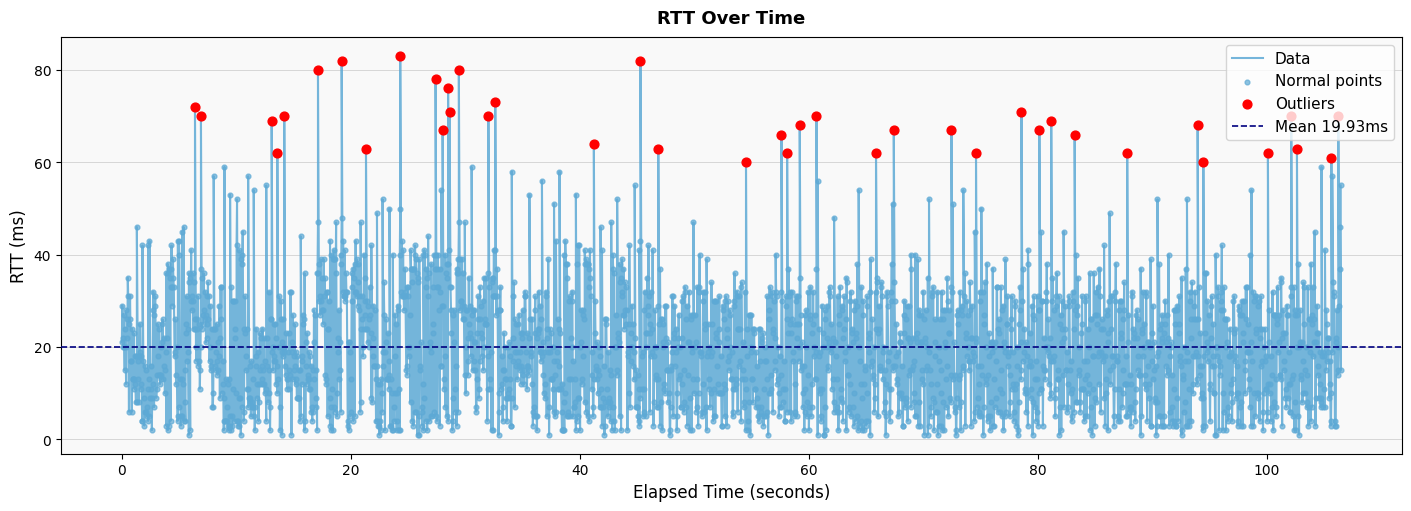

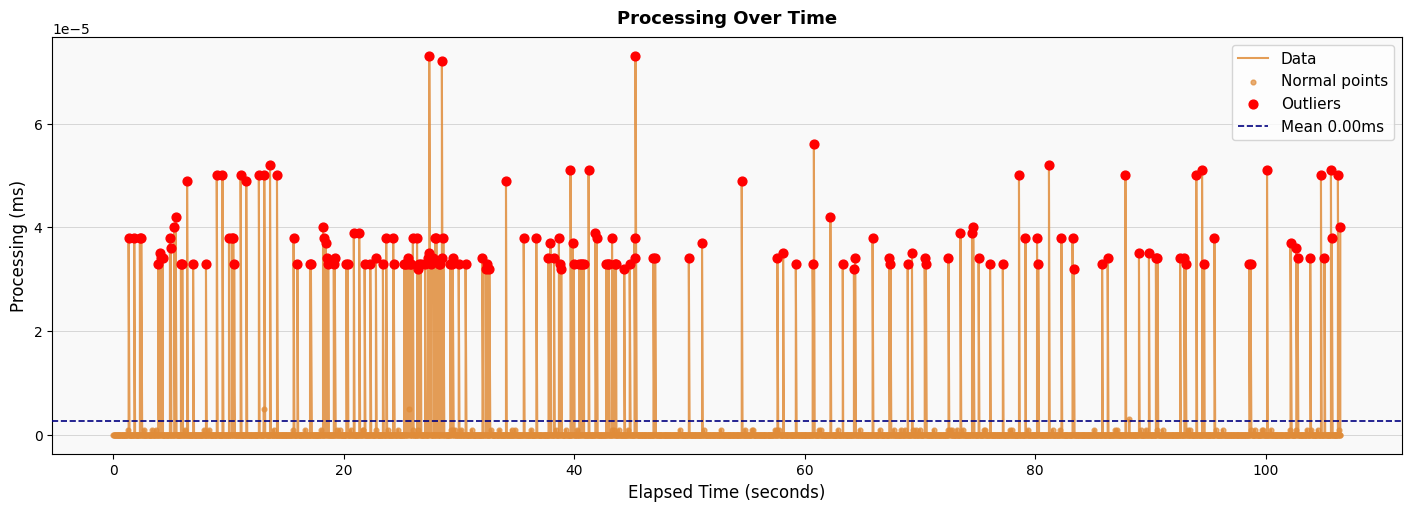

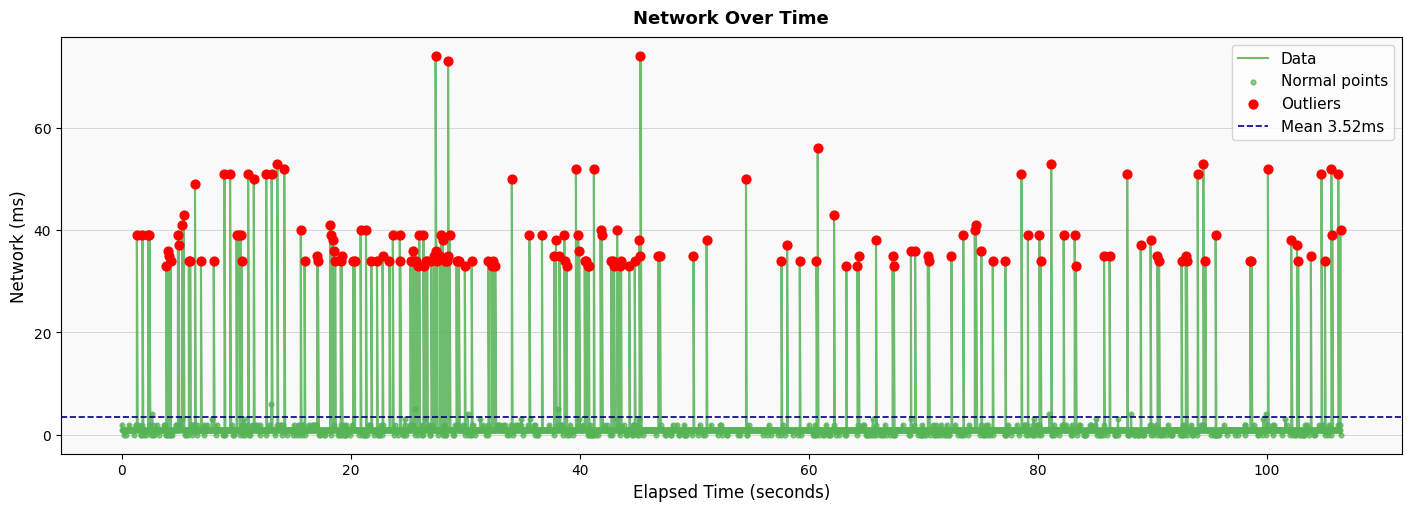

Skipping RenderDelay_ms - not found in DataFrame.
Skipping MTP_ms - not found in DataFrame.


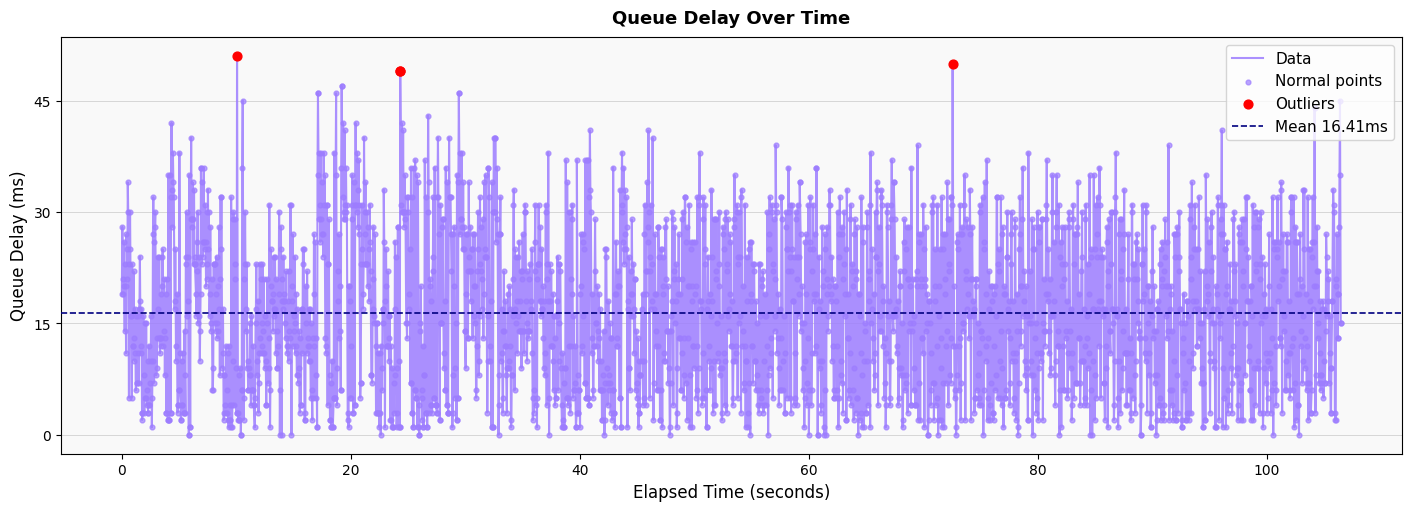

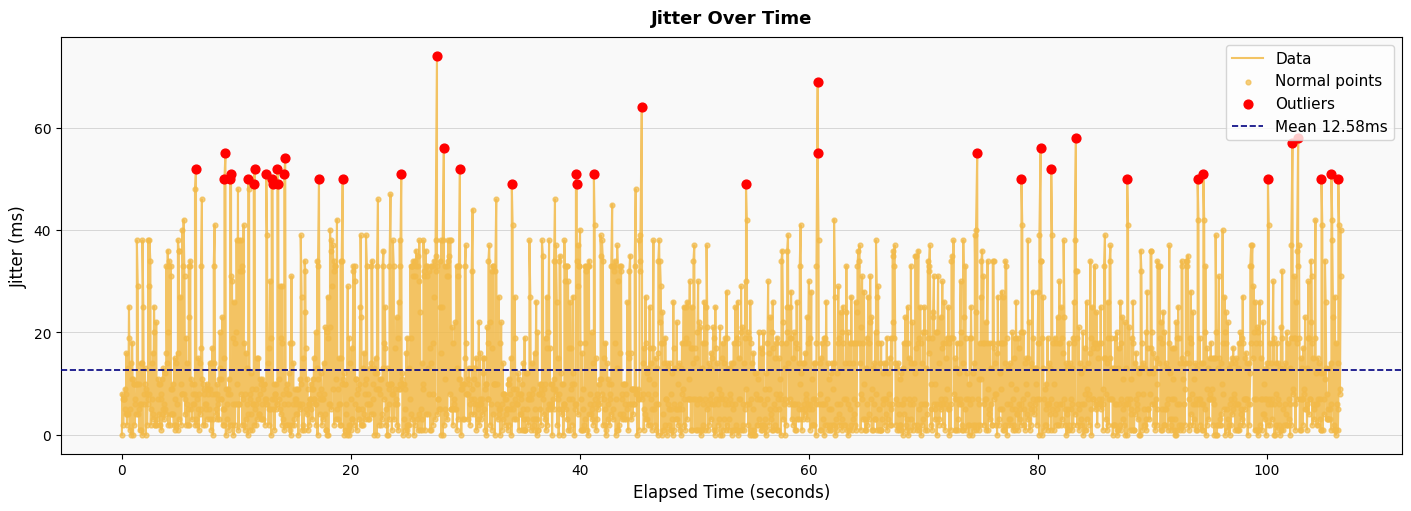

In [43]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Ensure Processing_ms exists
if "Processing_ns" in df.columns and "Processing_ms" not in df.columns:
    df["Processing_ms"] = df["Processing_ns"] / 1000000.0

# Ensure MTP_ms exists, if possible (MTP is usually t7 - t1_echo)
col_t1 = next((c for c in df.columns if c.startswith("t1")), "t1_echo")
col_t7 = next((c for c in df.columns if "t7" in c), "t7")
if col_t7 in df.columns and col_t1 in df.columns and "MTP_ms" not in df.columns:
    df["MTP_ms"] = (df[col_t7] - df[col_t1]).clip(lower=0)

# Generate an elapsed time axis if `elapsed_s` doesn't exist
if "elapsed_s" not in df.columns:
    if col_t1 in df.columns and not df[col_t1].isna().all():
        df["elapsed_s"] = (df[col_t1] - df[col_t1].iloc[0]) / 1000.0
    else:
        df["elapsed_s"] = range(len(df))

# Set an Outlier Threshold
OUTLIER_THRESHOLD = 3

# Define panels
panels = [
    dict(col="RTT_ms",         label="RTT (ms)",           color="#5da9d5", title="RTT Over Time"),
    dict(col="Processing_ms",  label="Processing (ms)",    color="#e08c39", title="Processing Over Time"),
    dict(col="Network_ms",     label="Network (ms)",       color="#56b356", title="Network Over Time"),
    dict(col="RenderDelay_ms", label="Render Delay (ms)",  color="#d14f4f", title="Render Delay Over Time"),
    dict(col="MTP_ms",         label="MTP (ms)",           color="#9d7dbf", title="Motion-to-Photon (MTP) Over Time"),
    dict(col="QueueDelay_ms",  label="Queue Delay (ms)",   color="#9d7dff", title="Queue Delay Over Time"),
    dict(col="Jitter_ms",      label="Jitter (ms)",        color="#f2ba49", title="Jitter Over Time")
]

x = df["elapsed_s"].values

print("Generating individual diagnostic plots...")

# Create separate figure for each metric
for p in panels:
    if p["col"] not in df.columns:
        print(f"Skipping {p['col']} - not found in DataFrame.")
        continue

    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

    y      = df[p["col"]].fillna(0).values
    mean   = y.mean()
    std    = y.std()
    is_out = y > mean + OUTLIER_THRESHOLD * std

    # Main line
    ax.plot(x, y, color=p["color"], linewidth=1.5, alpha=0.85, zorder=2, label="Data")

    # Normal scatter points
    ax.scatter(x[~is_out], y[~is_out],
               color=p["color"], s=12, zorder=3, alpha=0.7, label="Normal points")

    # Outlier points in red
    if is_out.any():
        ax.scatter(x[is_out], y[is_out],
                   color="red", s=40, zorder=5, label="Outliers")

    # Mean dashed line
    ax.axhline(mean, color="navy", linewidth=1.2, linestyle="--", zorder=4, label=f"Mean {mean:.2f}ms")

    # Legend
    ax.legend(loc="upper right", fontsize=11, framealpha=0.8)

    ax.set_title(p["title"], fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Elapsed Time (seconds)", fontsize=12)
    ax.set_ylabel(p["label"], fontsize=12)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(axis="y", color="gray", linewidth=0.4, alpha=0.5)
    ax.set_facecolor("#f9f9f9")

    plt.show()